# 扩散模型完整讲解 Notebook


## 0. 导入库

In [6]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms


def setup_chinese_font():
    """注册并启用 Windows 中文字体，解决 matplotlib 中文乱码。"""
    font_paths = [
        Path(r"C:\Windows\Fonts\msyh.ttc"),    # 微软雅黑
        Path(r"C:\Windows\Fonts\simhei.ttf"),   # 黑体
        Path(r"C:\Windows\Fonts\simsun.ttc"),   # 宋体
    ]
    for fp in font_paths:
        if fp.exists():
            font_manager.fontManager.addfont(str(fp))
            name = font_manager.FontProperties(fname=str(fp)).get_name()
            plt.rcParams["font.sans-serif"] = [name]
            plt.rcParams["axes.unicode_minus"] = False
            print(f"matplotlib 中文字体: {name}")
            return name
    plt.rcParams["axes.unicode_minus"] = False
    print("警告: 未找到中文字体文件，图表中文可能显示为方框")
    return None


setup_chinese_font()

NOTEBOOK_DIR = Path('.').resolve()
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

print(f"Notebook 目录: {NOTEBOOK_DIR}")
print(f"计算设备: {device}")

matplotlib 中文字体: Microsoft YaHei
Notebook 目录: E:\code\python\研究小代码\difussion
计算设备: cpu


## 1. `SinusoidalTimeEmbedding` — 时间步编码

把整数时间步 `t` 编码为高维向量，让网络感知当前噪声强度。

- 输入 `t`: `(B,)`
- 输出 `emb`: `(B, dim)`

In [ ]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    正弦时间步编码。
    输入: t (B,) 整数时间步  ->  输出: emb (B, dim) 连续向量
    核心公式: emb_i = sin(t * ω_i) 或 cos(t * ω_i)
    """

    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim  # 输出嵌入向量的维度

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # 步骤 1：获取 t 所在设备，确保后续张量与 t 同设备（CPU/CUDA）
        device = t.device

        # 步骤 2：取 dim 的一半，sin 和 cos 各占一半维度
        # 例: dim=16 -> half=8，最终拼接 8 个 sin + 8 个 cos = 16 维
        half = self.dim // 2

        # 步骤 3：生成 half 个不同频率 ω_i
        # 公式: ω_i = exp(-log(10000) * i / half)，i = 0,1,...,half-1
        # shape: (half,)
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=device) / half)

        # 步骤 4：计算相位 angle = t * ω_i
        # t: (B,) -> (B,1)，freqs: (half,) -> (1,half)，广播相乘得 (B,half)
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)

        # 步骤 5：对相位分别取 sin 和 cos，在最后一维拼接
        # sin(args): (B,half), cos(args): (B,half) -> cat -> (B, 2*half) = (B, dim)
        emb = torch.cat([args.sin(), args.cos()], dim=-1)

        # 步骤 6：若 dim 为奇数，末尾补一列 0 对齐维度
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        # 输出: (B, dim)，每个时间步 t 对应唯一的高维向量
        return emb

print("SinusoidalTimeEmbedding 已定义")

输入 t: [0, 50, 100, 199]
输出 shape: (4, 16)
输出 emb: tensor([[ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000],
        [-0.2624, -0.1032, -0.9589,  0.9999,  0.4794,  0.1575,  0.0500,  0.0158,
          0.9650, -0.9947,  0.2837, -0.0103,  0.8776,  0.9875,  0.9988,  0.9999],
        [-0.5064,  0.2054, -0.5440, -0.0207,  0.8415,  0.3110,  0.0998,  0.0316,
          0.8623,  0.9787, -0.8391, -0.9998,  0.5403,  0.9504,  0.9950,  0.9995],
        [-0.8818,  0.0973,  0.8676,  0.0097,  0.9134,  0.5886,  0.1977,  0.0629,
         -0.4716,  0.9953,  0.4972,  1.0000, -0.4070,  0.8084,  0.9803,  0.9980]])


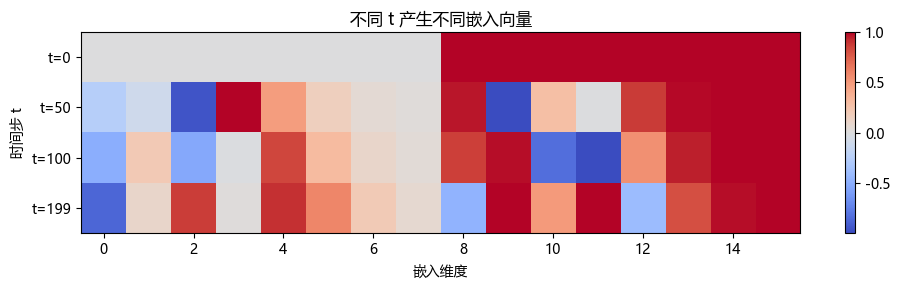

In [7]:
time_embed = SinusoidalTimeEmbedding(dim=16)
t = torch.tensor([0, 50, 100, 199])
emb = time_embed(t)

print("输入 t:", t.tolist())
print("输出 shape:", tuple(emb.shape))
print("输出 emb:", emb)

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(emb.detach().numpy(), aspect="auto", cmap="coolwarm")
ax.set_xlabel("嵌入维度"); ax.set_ylabel("时间步 t")
ax.set_yticks(range(len(t)))
ax.set_yticklabels([f"t={v}" for v in t.tolist()])
ax.set_title("不同 t 产生不同嵌入向量")
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

## 2. `SimpleUNet` — 去噪网络

**作用**：读入带噪图 `x_t` 和时间步 `t`，预测其中的高斯噪声 ε。

| 项目 | shape | 说明 |
|------|-------|------|
| 输入 `x` | `(B, C, H, W)` | 带噪图像，如 `(2, 1, 28, 28)` |
| 输入 `t` | `(B,)` | 每个样本的扩散时间步，0~T-1 |
| 输出 | `(B, C, H, W)` | 预测噪声 ε_θ，与 `x` 同 shape |

![A`L1JQPTV9]])`2DR2%RK1F.png](attachment:02fea041-3574-44ca-9f3c-f85b8d8a6f8e.png)
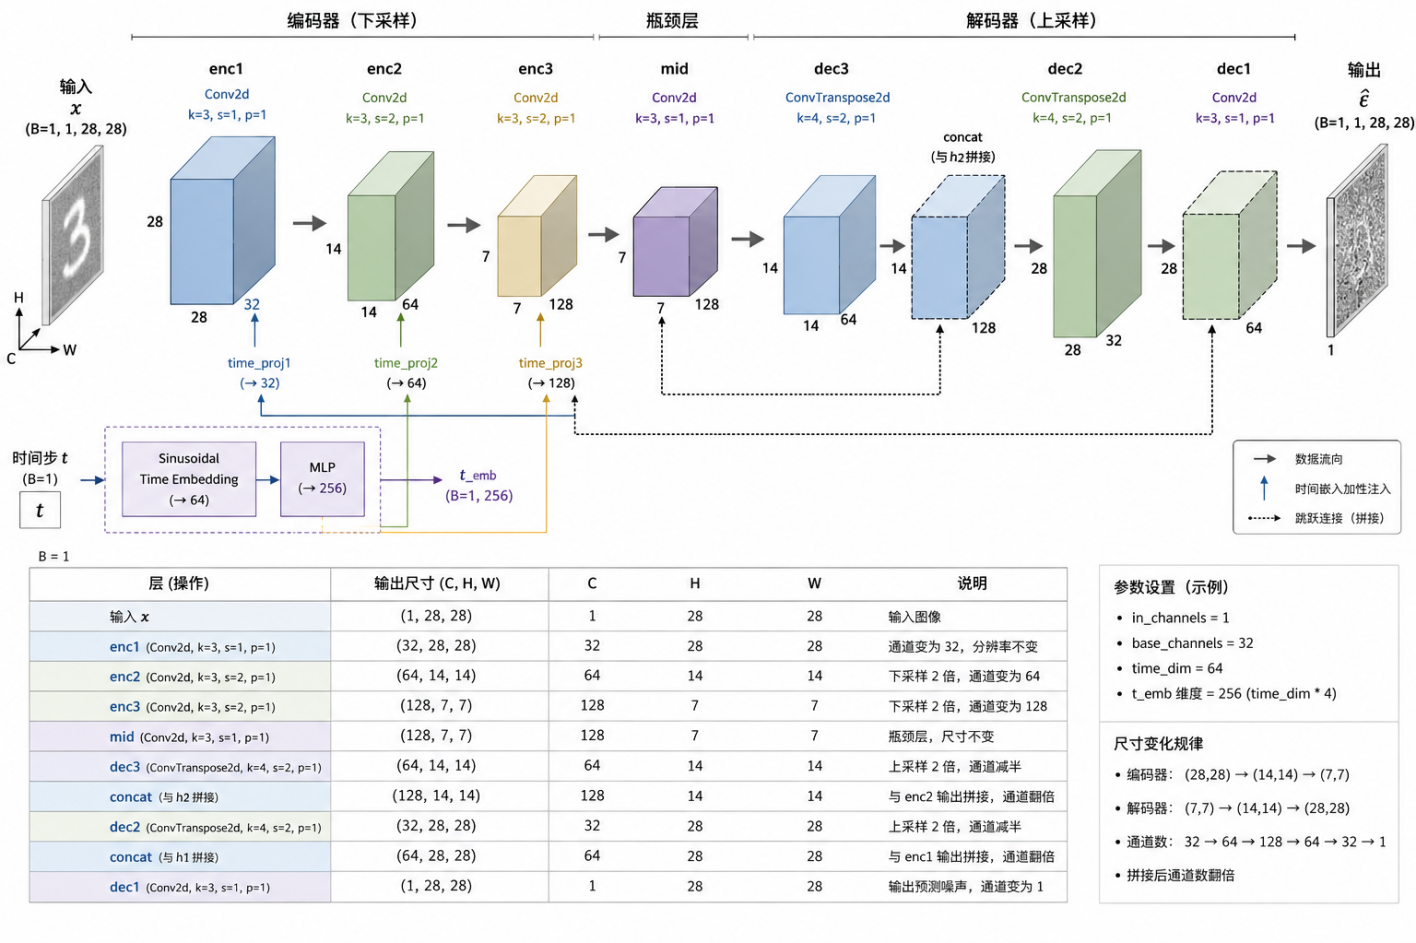

In [13]:
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, base_channels=32, time_dim=64):
        super().__init__()
        # 时间嵌入 MLP：t -> sin/cos 编码 -> 线性层 -> 256 维向量
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim * 4), nn.SiLU(),
            nn.Linear(time_dim * 4, time_dim * 4),
        )
        # 编码器：28x28 -> 14x14 -> 7x7，逐步下采样
        self.enc1 = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        self.enc2 = nn.Conv2d(base_channels, base_channels*2, 3, stride=2, padding=1)
        self.enc3 = nn.Conv2d(base_channels*2, base_channels*4, 3, stride=2, padding=1)
        # 瓶颈层：最深层特征融合
        self.mid = nn.Conv2d(base_channels*4, base_channels*4, 3, padding=1)
        # 解码器：7x7 -> 14x14 -> 28x28，逐步上采样
        self.dec3 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 4, stride=2, padding=1)
        self.dec2 = nn.ConvTranspose2d(base_channels*2*2, base_channels, 4, stride=2, padding=1)
        self.dec1 = nn.Conv2d(base_channels*2, in_channels, 3, padding=1)
        # 时间条件投影：将 t 嵌入映射到各层通道，用于加性注入
        self.time_proj1 = nn.Linear(time_dim*4, base_channels)
        self.time_proj2 = nn.Linear(time_dim*4, base_channels*2)
        self.time_proj3 = nn.Linear(time_dim*4, base_channels*4)

    def forward(self, x, t):
        # 默认 base_channels=32, in_channels=1, 输入图像 28x28
        # 输入 x: (B, 1, 28, 28), 输入 t: (B,)

        # 步骤 1：时间步 t -> 高维嵌入，将时间信息转换为噪声强度信息
        t_emb = self.time_mlp(t)  # (B,) -> (B, 256)  即 (B, time_dim*4)

        # 步骤 2：编码路径（下采样），每层注入 t_emb
        h1 = F.silu(self.enc1(x) + self.time_proj1(t_emb).unsqueeze(-1).unsqueeze(-1))
        # enc1(x): (B,1,28,28)->(B,32,28,28),  t_proj: (B,256)->(B,32,1,1) 广播加（图中每个像素点都加上t_proj）
        # h1: (B, 32, 28, 28)

        h2 = F.silu(self.enc2(h1) + self.time_proj2(t_emb).unsqueeze(-1).unsqueeze(-1))
        # enc2(h1): (B,32,28,28)->(B,64,14,14),  t_proj: (B,256)->(B,64,1,1) 广播加
        # h2: (B, 64, 14, 14)

        h3 = F.silu(self.enc3(h2) + self.time_proj3(t_emb).unsqueeze(-1).unsqueeze(-1))
        # enc3(h2): (B,64,14,14)->(B,128,7,7),  t_proj: (B,256)->(B,128,1,1) 广播加
        # h3: (B, 128, 7, 7)

        # 步骤 3：瓶颈层
        h = F.silu(self.mid(h3))  # (B,128,7,7) -> (B,128,7,7)

        # 步骤 4：解码路径（上采样）+ 跳跃连接
        h = F.silu(self.dec3(h))       # (B,128,7,7) -> (B,64,14,14)
        h = torch.cat([h, h2], dim=1)  # (B,64,14,14)+(B,64,14,14) -> (B,128,14,14)
        h = F.silu(self.dec2(h))       # (B,128,14,14) -> (B,32,28,28)
        h = torch.cat([h, h1], dim=1)  # (B,32,28,28)+(B,32,28,28) -> (B,64,28,28)

        # 步骤 5：输出预测噪声
        return self.dec1(h)  # (B,64,28,28) -> (B,1,28,28)


SimpleUNet 输入输出（1.jpg, t=50）
原图 x0        shape: (1, 1, 28, 28), 值域: [0.17, 0.98]
输入 x (带噪图) shape: (1, 1, 28, 28), 值域: [-1.56, 1.48]
输入 t (时间步) shape: (1,), 值: [50]
---------------------
时间步编码，告诉模型噪声强度
噪声强度 emb shape: torch.Size([1, 64])
---------------------
输出 pred_noise shape: (1, 1, 28, 28), 值域: [-0.23, 0.17]
shape 一致: True

含义: 网络读入 1.jpg 的带噪版本 + 时间步 t，输出它认为的噪声


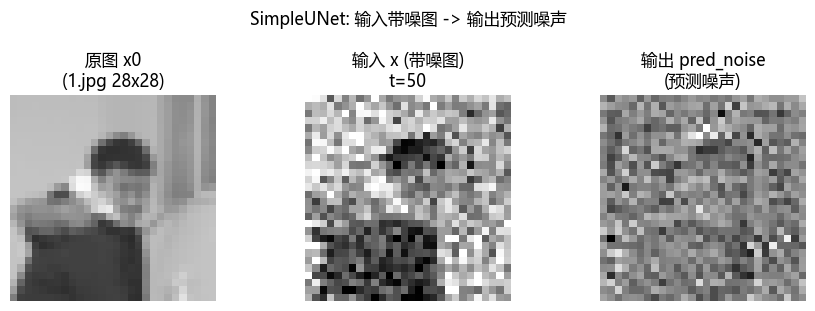

In [17]:
# --- 演示：SimpleUNet 输入输出（以 1.jpg 为例）---
unet = SimpleUNet(1, 32).to(device)
unet.eval()

# 1. 读取 1.jpg，预处理为 x0
image_path = NOTEBOOK_DIR / "1.jpg"
img = Image.open(image_path).convert("L")
x0 = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
])(img).unsqueeze(0)                    # (1,1,28,28), 像素 [0,1]
x0_norm = (x0 * 2 - 1).to(device)         # 映射到 [-1,1]

# 2. 在 t=50 对 x0 加噪，构造带噪输入 x_t（前向扩散公式）
t_val = 50
betas = torch.linspace(1e-4, 0.02, 200, device=device)
alpha_bar = torch.cumprod(1 - betas, dim=0)[t_val]
torch.manual_seed(42)
true_noise = torch.randn_like(x0_norm)
x_noisy = torch.sqrt(alpha_bar) * x0_norm + torch.sqrt(1 - alpha_bar) * true_noise

# 3. 送入 SimpleUNet
t = torch.tensor([t_val], device=device)
pred_noise = unet(x_noisy, t)

print("=" * 50)
print("SimpleUNet 输入输出（1.jpg, t=50）")
print("=" * 50)
print(f"原图 x0        shape: {tuple(x0.shape)}, 值域: [{x0.min():.2f}, {x0.max():.2f}]")
print(f"输入 x (带噪图) shape: {tuple(x_noisy.shape)}, 值域: [{x_noisy.min():.2f}, {x_noisy.max():.2f}]")
print(f"输入 t (时间步) shape: {tuple(t.shape)}, 值: {t.tolist()}")

print('---------------------')
print("时间步编码，告诉模型噪声强度")
time_embed = SinusoidalTimeEmbedding(dim=64)
emb = time_embed(t)
print("噪声强度 emb shape:", emb.shape)

print('---------------------')
print(f"输出 pred_noise shape: {tuple(pred_noise.shape)}, 值域: [{pred_noise.min():.2f}, {pred_noise.max():.2f}]")
print(f"shape 一致: {x_noisy.shape == pred_noise.shape}")
print("\n含义: 网络读入 1.jpg 的带噪版本 + 时间步 t，输出它认为的噪声")

# 4. 可视化：原图 | 带噪输入 | 预测噪声
def show_img(ax, tensor, title, cmap="gray", is_noise=False):
    img = tensor[0, 0].detach().cpu()
    if is_noise:
        # 噪声有正有负，归一化到 [0,1] 便于显示
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    else:
        img = (img.clamp(-1, 1) + 1) / 2
    ax.imshow(img.numpy(), cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title); ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
show_img(axes[0], x0_norm.cpu(), "原图 x0\n(1.jpg 28x28)")
show_img(axes[1], x_noisy.cpu(), f"输入 x (带噪图)\nt={t_val}")
show_img(axes[2], pred_noise.cpu(), "输出 pred_noise\n(预测噪声)", is_noise=True)
plt.suptitle("SimpleUNet: 输入带噪图 -> 输出预测噪声", y=1.02)
plt.tight_layout(); plt.show()

## 3. `DiffusionModel` — DDPM 核心

**作用**：管理噪声调度表，封装前向加噪、训练损失、反向采样。

| 方法 | 输入 | 输出 | 用途 |
|------|------|------|------|
| `q_sample` | x0, t, noise | x_t, noise | **前向加噪** |
| `p_losses` | x0, t | loss | 训练 |
| `sample` | batch_size, device | 生成图x | **反向去噪** |


In [ ]:
class DiffusionModel(nn.Module):
    """
    DDPM 扩散模型：噪声调度 + 前向加噪 + 训练损失 + 反向采样。

    前向公式: x_t = sqrt(alpha_bar)*x0 + sqrt(1-alpha_bar)*noise
    训练目标: MSE(真实噪声, 预测噪声)
    反向采样: 从 x_T ~ N(0,I) 逐步去噪到 x_0
    """

    def __init__(self, net, image_size=28, in_channels=1, timesteps=200,
                 beta_start=1e-4, beta_end=0.02):
        super().__init__()
        self.net = net
        self.image_size = image_size
        self.in_channels = in_channels
        self.timesteps = timesteps

        # 步骤 1：线性调度 beta_t（每步加噪量）
        betas = torch.linspace(beta_start, beta_end, timesteps)
        # 步骤 2：alpha_t = 1 - beta_t（每步保留信号比例）
        alphas = 1.0 - betas
        # 步骤 3：alpha_bar_t = 累积乘积（从 x0 到 x_t 的总保留比例）
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        # 步骤 4：预计算常用系数（噪声调度表），注册为 buffer（不参与梯度，随模型移动设备）          # 加噪声后的新图像：x_t = √ᾱ·x0 + √(1-ᾱ)·noise 
        self.register_buffer('betas', betas)                                                  # 每步噪声方差 β_t 
        self.register_buffer('alphas_cumprod', alphas_cumprod)                                # 累积信号保留比例ᾱ_t = ∏α
        self.register_buffer('sqrt_alphas_cumprod', torch.sqrt(alphas_cumprod))               # √ᾱ
        self.register_buffer('sqrt_one_minus_alphas_cumprod', torch.sqrt(1 - alphas_cumprod)) # √(1-ᾱ) 
        self.register_buffer('sqrt_recip_alphas', torch.sqrt(1 / alphas))                     # √(1/α) 
        # 反向采样时的后验方差
        posterior_variance = betas * (1 - alphas_cumprod_prev) / (1 - alphas_cumprod)
        self.register_buffer('posterior_variance', posterior_variance)

    def _extract(self, values, t, x_shape):
        """
        按 batch 中每个样本的时间步 t，从 1D 调度表取值并 reshape 为 (B,1,1,1)。
        输入: values (T,), t (B,), x_shape
        输出: (B, 1, 1, 1)，可与 (B,C,H,W) 广播运算
        """
        b = t.shape[0]
        return values.gather(0, t).view(b, *((1,) * (len(x_shape) - 1)))

    def q_sample(self, x0, t, noise=None):
        """
        前向加噪（一步闭式解）。
        输入: x0 (B,C,H,W) 干净图, t (B,) 时间步, noise 可选
        输出: x_t (B,C,H,W) 加噪图, noise (B,C,H,W) 使用的噪声
        """
        # 步骤 1：采样高斯噪声 epsilon ~ N(0,I)
        if noise is None:
            noise = torch.randn_like(x0)
        # 步骤 2：取 sqrt(alpha_bar) 和 sqrt(1-alpha_bar)
        sqrt_alpha = self._extract(self.sqrt_alphas_cumprod, t, x0.shape)
        sqrt_one_minus = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x0.shape)
        # 步骤 3：生成噪声图像x_t = sqrt(alpha_bar)*x0 + sqrt(1-alpha_bar)*noise
        x_t = sqrt_alpha * x0 + sqrt_one_minus * noise
        return x_t, noise

    def p_losses(self, x0, t):
        """
        训练损失：MSE(真实噪声, 网络预测噪声)。
        输入: x0 (B,C,H,W), t (B,)
        输出: 标量 loss
        """
        noise = torch.randn_like(x0)              # 步骤 1：采样噪声 x->x_t中实际加入的噪声noise
        x_t, _ = self.q_sample(x0, t, noise)      # 步骤 2：加噪得 x_t
        pred_noise = self.net(x_t, t)             # 步骤 3：网络预测 x_t时被加入的噪声pred_noise
        return F.mse_loss(pred_noise, noise)      # 步骤 4：MSE 损失

    @torch.no_grad()
    def sample(self, batch_size, device):
        """
        反向去噪采样：从纯噪声逐步生成图像。
        输入: batch_size 生成数量, device 设备
        输出: (batch_size, C, H, W) 生成样本，值域约 [-1,1]
        """
        # 步骤 1：从 x_T ~ N(0,I) 初始化
        x = torch.randn(batch_size, self.in_channels, self.image_size,
                        self.image_size, device=device)

        # 步骤 2：从 t=T-1 倒序到 t=0，逐步去噪
        for step in reversed(range(self.timesteps)):
            t = torch.full((batch_size,), step, device=device, dtype=torch.long)
            pred_noise = self.net(x, t)   # 预测当前噪声

            beta_t = self._extract(self.betas, t, x.shape)
            sqrt_one_minus = self._extract(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
            sqrt_recip_alpha = self._extract(self.sqrt_recip_alphas, t, x.shape)

            # 步骤 3：计算后验均值（去噪方向） mean ≈ 去噪后的 x_{t-1}时刻图像
            mean = sqrt_recip_alpha * (x - beta_t / sqrt_one_minus * pred_noise)

            # 步骤 4：t>0 加一点随机噪声增加鲁棒性；t=0 直接输出
            if step > 0:
                var = self._extract(self.posterior_variance, t, x.shape)
                x = mean + torch.sqrt(var) * torch.randn_like(x)
            else:
                x = mean

        return x

print("DiffusionModel 已定义")

DiffusionModel 已定义


【1. 初始化模型】

【2. 前向加噪 q_sample】
公式: x_t = sqrt(alpha_bar)*x0 + sqrt(1-alpha_bar)*noise


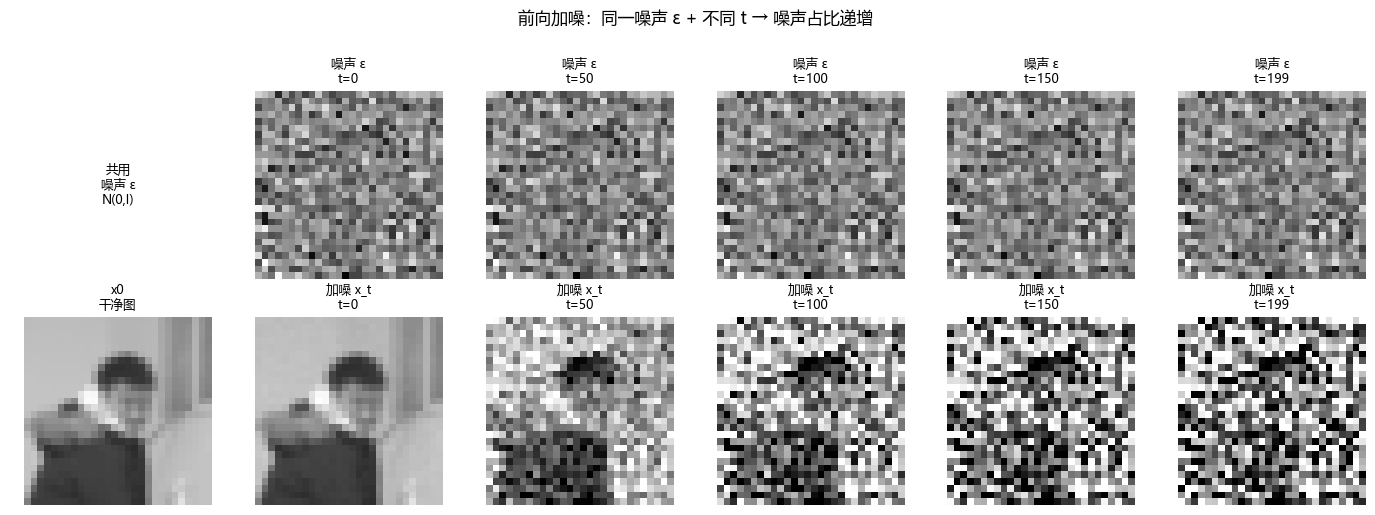

In [37]:
# --- DiffusionModel 演示：初始化 + 前向加噪 ---
# [更新] Loss 举例见下一个 Cell；反向去噪三行图见再下一个 Cell

def _show(ax, tensor, title, is_noise=False):
    img = tensor[0, 0].detach().cpu()
    if is_noise:
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    else:
        img = (img.clamp(-1, 1) + 1) / 2
    ax.imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

image_path = NOTEBOOK_DIR / "1.jpg"
img = Image.open(image_path).convert("L")
x0 = transforms.Compose([transforms.Resize((28, 28)), transforms.ToTensor()])(img).unsqueeze(0)
x0_train = (x0 * 2 - 1).to(device)  # 干净图 x0，shape (1,1,28,28)


#-----------------------------------加噪声过程核心代码----------------------------------------------

print("【1. 初始化模型】")
TIMESTEPS = 200
model = DiffusionModel(SimpleUNet(1, 32), image_size=28, in_channels=1,
                       timesteps=TIMESTEPS).to(device)

print("\n【2. 前向加噪 q_sample】")
print("公式: x_t = sqrt(alpha_bar)*x0 + sqrt(1-alpha_bar)*noise")

# 噪声图fixed_noise（加噪过程每一步用的是同一个噪声----仅演示用，实际每步为随机噪声）
torch.manual_seed(42)
fixed_noise = torch.randn_like(x0_train)

fwd_steps = [0, 50, 100, 150, 199]  # fwd_steps: 要演示的时间步列表

# 每一步加噪声得到下一个新图x_t
x_t_snap = {}  # x_t_snap: 各 t 加噪后的图像，key=时间步
for tv in fwd_steps:
    t = torch.tensor([tv], device=device)  # t: 当前时间步，shape (1,)
    x_t, _ = model.q_sample(x0_train, t, fixed_noise) # x_t: 加噪结果，shape (1,1,28,28)
    x_t_snap[tv] = x_t.cpu()

# -------------------------------------------



n_cols = 1 + len(fwd_steps)  
fig, axes = plt.subplots(2, n_cols, figsize=(14, 5))

# 第1列：干净原图（第2行），第1行标注噪声来源
axes[0, 0].set_facecolor("#f0f0f0")
axes[0, 0].text(0.5, 0.5, "共用\n噪声 ε\nN(0,I)", ha="center", va="center", fontsize=9)
axes[0, 0].axis("off")
_show(axes[1, 0], x0_train.cpu(), "x0\n干净图")

for col, tv in enumerate(fwd_steps, start=1):
    # 第1行：真实噪声 ε（各列相同，因 fixed_noise 共用）
    _show(axes[0, col], fixed_noise.cpu(), f"噪声 ε\nt={tv}", is_noise=True)
    # 第2行：该 t 加噪后的 x_t
    _show(axes[1, col], x_t_snap[tv], f"加噪 x_t\nt={tv}")

axes[0, 0].set_ylabel("第1行:\n噪声 ε", fontsize=10)
axes[1, 0].set_ylabel("第2行:\n加噪 x_t", fontsize=10)
plt.suptitle("前向加噪：同一噪声 ε + 不同 t → 噪声占比递增", y=1.02)
plt.tight_layout()
plt.show()


【Loss 计算流程（训练步 t=1）】
  干净图 x0:  shape (1, 1, 28, 28)（未入 Loss，仅作前向起点）
  ① 采样真实噪声 ε ~ N(0,I):  shape (1, 1, 28, 28)
  ② 前向得 x_1 = 0.9998·x0 + 0.0173·ε
  ③ 前向得 x_2 = 0.9997·x0 + 0.0245·ε  （同一 ε，t 更大 → 更糊，仅作对比）
  ④ pred_ε = net(x_1, t=1):  shape (1, 1, 28, 28)
  ⑤ Loss = MSE(pred_ε, ε) = 0.982589
  ※ Loss 比较的是 **pred_ε 与 ε** 两个噪声张量（同 shape 1×1×28×28）
     不是 x_1 与 pred_ε，也不是 x_1 与 x_2 等「图像 vs 图像」


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6852\767112058.py:43: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6852\767112058.py:43: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()


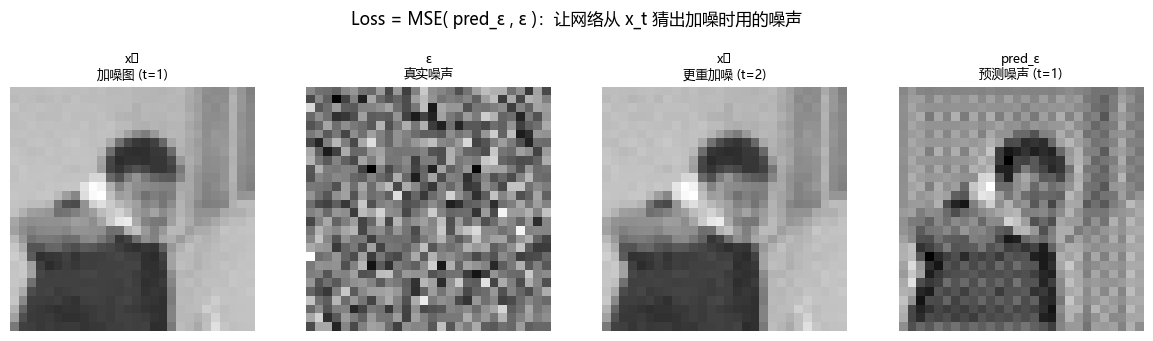

In [42]:
# --- Loss 举例：完整计算过程（1.jpg, t=1 训练 / 展示 x_2）---
# 请先运行上一个 Cell（已有 model, x0_train, device）
# 绘制：x_1 加噪图 | 真实噪声 ε | x_2 更重加噪图 | t=1 时预测噪声 pred_ε | Loss 比较哪两个量

t_loss = 1   # 本例在 t=1 上算 Loss：x_1 → net 预测 ε → 与真实 ε 比 MSE
t_show = 2   # 额外展示 t=2 的 x_2，说明前向链上噪声逐步加重

torch.manual_seed(123)
noise_demo = torch.randn_like(x0_train)  # 本步固定 ε，用于生成 x_1、x_2
t1 = torch.tensor([t_loss], device=device)
t2 = torch.tensor([t_show], device=device)

x_1, _ = model.q_sample(x0_train, t1, noise_demo)   # x_1：t=1 加噪图
x_2, _ = model.q_sample(x0_train, t2, noise_demo)   # x_2：同一 ε、更大 t 的加噪图

model.eval()
with torch.no_grad():
    pred_noise = model.net(x_1, t1)  # 在 x_1 上、时间步 t=1 预测噪声

loss_manual = F.mse_loss(pred_noise, noise_demo).item()

sa1 = model.sqrt_alphas_cumprod[t_loss].item()
s1a1 = model.sqrt_one_minus_alphas_cumprod[t_loss].item()
sa2 = model.sqrt_alphas_cumprod[t_show].item()
s1a2 = model.sqrt_one_minus_alphas_cumprod[t_show].item()

print("【Loss 计算流程（训练步 t=1）】")
print(f"  干净图 x0:  shape {tuple(x0_train.shape)}（未入 Loss，仅作前向起点）")
print(f"  ① 采样真实噪声 ε ~ N(0,I):  shape {tuple(noise_demo.shape)}")
print(f"  ② 前向得 x_1 = {sa1:.4f}·x0 + {s1a1:.4f}·ε")
print(f"  ③ 前向得 x_2 = {sa2:.4f}·x0 + {s1a2:.4f}·ε  （同一 ε，t 更大 → 更糊，仅作对比）")
print(f"  ④ pred_ε = net(x_1, t=1):  shape {tuple(pred_noise.shape)}")
print(f"  ⑤ Loss = MSE(pred_ε, ε) = {loss_manual:.6f}")
print("  ※ Loss 比较的是 **pred_ε 与 ε** 两个噪声张量（同 shape 1×1×28×28）")
print("     不是 x_1 与 pred_ε，也不是 x_1 与 x_2 等「图像 vs 图像」")

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
_show(axes[0], x_1.cpu(), f"x₁\n加噪图 (t={t_loss})")
_show(axes[1], noise_demo.cpu(), "ε\n真实噪声", is_noise=True)
_show(axes[2], x_2.cpu(), f"x₂\n更重加噪 (t={t_show})")
_show(axes[3], pred_noise.cpu(), f"pred_ε\n预测噪声 (t={t_loss})", is_noise=True)
plt.suptitle("Loss = MSE( pred_ε , ε )：让网络从 x_t 猜出加噪时用的噪声", y=1.05)
plt.tight_layout()
plt.show()




【3b. 反向去噪 — 三行：预测噪声 | 去噪前 | 去噪后】
  t=199->198 | pred | 去噪前 | 去噪后
  t=150->149 | pred | 去噪前 | 去噪后
  t=100->99 | pred | 去噪前 | 去噪后
  t=50->49 | pred | 去噪前 | 去噪后


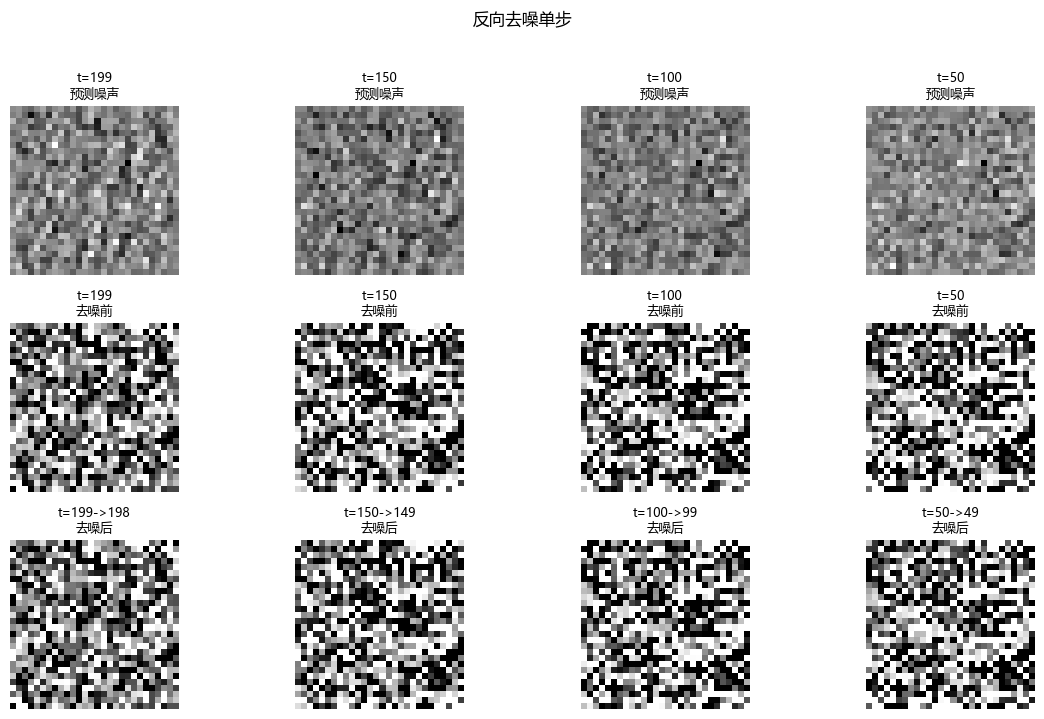

In [43]:
# --- 反向去噪三行图（预测噪声 | 去噪前 | 去噪后）---

def _show3(ax, tensor, title, is_noise=False):
    img = tensor[0, 0].detach().cpu()
    if is_noise:
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    else:
        img = (img.clamp(-1, 1) + 1) / 2
    ax.imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

# 若尚未训练，先快速训练 2 epoch
if not hasattr(model, "_demo_trained"):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loader = torch.utils.data.DataLoader(x0.repeat(16, 1, 1, 1), batch_size=4, shuffle=True)
    for ep in range(2):
        for batch in loader:
            xb = (batch.to(device) if not isinstance(batch, (list, tuple)) else batch[0].to(device)) * 2 - 1
            tt = torch.randint(0, model.timesteps, (xb.shape[0],), device=device)
            loss = model.p_losses(xb, tt)
            opt.zero_grad(); loss.backward(); opt.step()
        print(f"快速训练 epoch {ep+1}/2")
    model._demo_trained = True

print("\n" + "=" * 60)
print("【3b. 反向去噪 — 三行：预测噪声 | 去噪前 | 去噪后】")
print("=" * 60)

rev_steps = [199, 150, 100, 50]
# rev_steps: 要可视化的时间步列表，每列展示一次 t -> t-1 更新

x_before_snap = {}  # 去噪前的 x_t，key=时间步 step
pred_snap = {}      # 网络预测的噪声 pred，key=step
x_after_snap = {}   # 去噪后的 x_{t-1}，key=step

torch.manual_seed(123)
x = torch.randn(1, 1, 28, 28, device=device)
# x: 反向采样当前状态，初始为 x_T ~ N(0,I)，shape (1,1,28,28)

model.eval()
with torch.no_grad():
    for step in reversed(range(model.timesteps)):
        # step: 当前反向去噪时间步，从 199 递减到 0
        t = torch.full((1,), step, device=device, dtype=torch.long)
        # t: 当前 batch 的时间步张量，shape (1,)

        x_before = x.clone()
        # x_before: 本步更新前的带噪图 x_t，shape (1,1,28,28)

        pred = model.net(x, t)
        # pred: SimpleUNet 预测的噪声 ε_θ，shape (1,1,28,28)

        beta_t = model._extract(model.betas, t, x.shape)
        # beta_t: 调度系数 β_t，广播 shape (1,1,1,1)
        so = model._extract(model.sqrt_one_minus_alphas_cumprod, t, x.shape)
        # so: sqrt(1-alpha_bar_t)，广播 shape (1,1,1,1)
        sr = model._extract(model.sqrt_recip_alphas, t, x.shape)
        # sr: sqrt(1/alpha_t)，广播 shape (1,1,1,1)

        mean = sr * (x - beta_t / so * pred)
        # mean: DDPM 后验均值，去噪方向，shape 与 x 相同

        if step > 0:
            var = model._extract(model.posterior_variance, t, x.shape)
            # var: 后验方差，用于采样随机性
            x = mean + torch.sqrt(var) * torch.randn_like(x)
            # 更新 x 为 x_{t-1}（含随机噪声）
        else:
            x = mean
            # t=0 时直接输出均值作为最终生成图

        if step in rev_steps:
            x_before_snap[step] = x_before.cpu()
            pred_snap[step] = pred.cpu()
            x_after_snap[step] = x.clone().cpu()
            print(f"  t={step}->{step-1} | pred | 去噪前 | 去噪后")

fig, axes = plt.subplots(3, len(rev_steps), figsize=(12, 7))
for col, step in enumerate(rev_steps):
    _show3(axes[0, col], pred_snap[step], f"t={step}\n预测噪声", is_noise=True)
    _show3(axes[1, col], x_before_snap[step], f"t={step}\n去噪前")
    _show3(axes[2, col], x_after_snap[step], f"t={step}->{step-1}\n去噪后")
axes[0, 0].set_ylabel("第1行: pred")
axes[1, 0].set_ylabel("第2行: 去噪前")
axes[2, 0].set_ylabel("第3行: 去噪后")
plt.suptitle("反向去噪单步", y=1.02)
plt.tight_layout()
plt.show()


## 4. 训练与生成

- `train_one_epoch`：单轮训练（随机 t、MSE 损失、反向传播）
- 在 `1.jpg` 上训练 **20 轮**，权重保存为 `diffusion_1jpg.pth`
- 后续可 **加载 pth** 再调用 `model.sample()` 反向去噪生成


In [44]:
def train_one_epoch(model, loader, optimizer, device):
    model.train(); total, n = 0.0, 0
    for batch in loader:
        x0 = batch[0] if isinstance(batch,(list,tuple)) else batch
        x0 = x0.to(device)*2-1
        t = torch.randint(0, model.timesteps, (x0.shape[0],), device=device)
        loss = model.p_losses(x0, t)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item(); n += 1
    return total/max(n,1)

print("train_one_epoch 已定义")

train_one_epoch 已定义


### 4.1 训练 20 轮（1.jpg）

请先运行上文 Cell（已有 `model`、`x0_train`、`device`、`_show`）。
单张图会复制多份，使每轮有多次「随机 t + 随机噪声」的梯度更新。


训练集: 1 张图 × 64 份, batch_size=8, 共 100 轮
--------------------------------------------------
Epoch  1/100  avg_loss = 0.1017
Epoch  2/100  avg_loss = 0.1106
Epoch  3/100  avg_loss = 0.1079
Epoch  4/100  avg_loss = 0.0981
Epoch  5/100  avg_loss = 0.1594
Epoch  6/100  avg_loss = 0.1015
Epoch  7/100  avg_loss = 0.0621
Epoch  8/100  avg_loss = 0.0734
Epoch  9/100  avg_loss = 0.0577
Epoch 10/100  avg_loss = 0.0791
Epoch 11/100  avg_loss = 0.0974
Epoch 12/100  avg_loss = 0.1274
Epoch 13/100  avg_loss = 0.1298
Epoch 14/100  avg_loss = 0.0513
Epoch 15/100  avg_loss = 0.0496
Epoch 16/100  avg_loss = 0.0448
Epoch 17/100  avg_loss = 0.0541
Epoch 18/100  avg_loss = 0.0761
Epoch 19/100  avg_loss = 0.0646
Epoch 20/100  avg_loss = 0.0376
Epoch 21/100  avg_loss = 0.0782
Epoch 22/100  avg_loss = 0.0488
Epoch 23/100  avg_loss = 0.0774
Epoch 24/100  avg_loss = 0.0514
Epoch 25/100  avg_loss = 0.0643
Epoch 26/100  avg_loss = 0.0677
Epoch 27/100  avg_loss = 0.0442
Epoch 28/100  avg_loss = 0.0504
Epoch 29/100 

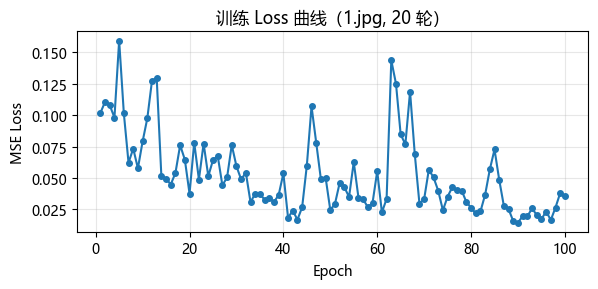

In [47]:
from torch.utils.data import DataLoader, TensorDataset

# --- 构造 DataLoader：1.jpg 复制 REPEAT 份，每 epoch 多步更新 ---
REPEAT = 64
BATCH_SIZE = 8
EPOCHS = 100
LR = 1e-3
WEIGHT_PATH = NOTEBOOK_DIR / "diffusion_1jpg.pth"  # 权重保存路径

# train_one_epoch 内部会做 x0*2-1，此处用 [0,1] 的 x0（勿用已归一化到 [-1,1] 的 x0_train）
train_x0 = x0.cpu().repeat(REPEAT, 1, 1, 1)
loader = DataLoader(TensorDataset(train_x0), batch_size=BATCH_SIZE, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_history = []

print(f"训练集: 1 张图 × {REPEAT} 份, batch_size={BATCH_SIZE}, 共 {EPOCHS} 轮")
print("-" * 50)
for ep in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(model, loader, optimizer, device)
    loss_history.append(avg_loss)
    print(f"Epoch {ep:2d}/{EPOCHS}  avg_loss = {avg_loss:.4f}")

print("-" * 50)
print(f"训练完成，最终 loss = {loss_history[-1]:.4f}")

# 保存权重（含结构超参，便于后续重建模型并加载）
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "timesteps": TIMESTEPS,
        "image_size": 28,
        "in_channels": 1,
        "base_channels": 32,
        "epochs": EPOCHS,
        "final_loss": loss_history[-1],
    },
    WEIGHT_PATH,
)
print(f"权重已保存: {WEIGHT_PATH.resolve()}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, EPOCHS + 1), loss_history, "o-", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("训练 Loss 曲线（1.jpg, 20 轮）")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 4.2 加载权重并反向采样生成

从 `diffusion_1jpg.pth` 重建模型、加载权重，再 `model.sample()` 生成。



已加载: diffusion_1jpg.pth  |  timesteps=200, final_loss=0.03573515615426004
生成完成: shape (4, 1, 28, 28)
流程: x_T ~ N(0,I)  →  t=T-1…0 逐步 net 预测噪声并去噪  →  x_0


C:\Users\Administrator\AppData\Local\Temp\ipykernel_6852\4082866036.py:46: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()


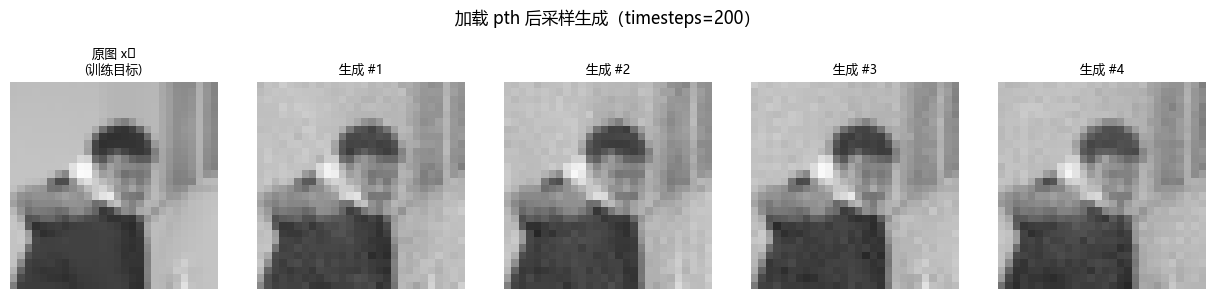

In [48]:
# --- 加载 pth 权重 ---
WEIGHT_PATH = NOTEBOOK_DIR / "diffusion_1jpg.pth"
ckpt = torch.load(WEIGHT_PATH, map_location=device)
TIMESTEPS = ckpt["timesteps"]

model = DiffusionModel(
    SimpleUNet(ckpt["in_channels"], ckpt["base_channels"]),
    image_size=ckpt["image_size"],
    in_channels=ckpt["in_channels"],
    timesteps=TIMESTEPS,
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"已加载: {WEIGHT_PATH.name}  |  timesteps={TIMESTEPS}, final_loss={ckpt.get('final_loss', 'N/A')}")

# --- 反向采样生成 ---
N_GEN = 4
with torch.no_grad():
    generated = model.sample(batch_size=N_GEN, device=device)

print(f"生成完成: shape {tuple(generated.shape)}")
print("流程: x_T ~ N(0,I)  →  t=T-1…0 逐步 net 预测噪声并去噪  →  x_0")

# 若内存中无 x0_train，重新读取 1.jpg 作对比
if "x0_train" not in globals():
    _img = Image.open(NOTEBOOK_DIR / "1.jpg").convert("L")
    _x0 = transforms.Compose([transforms.Resize((28, 28)), transforms.ToTensor()])(_img).unsqueeze(0)
    x0_train = (_x0 * 2 - 1).cpu()

if "_show" not in globals():
    def _show(ax, tensor, title, is_noise=False):
        img = tensor[0, 0].detach().cpu()
        if is_noise:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        else:
            img = (img.clamp(-1, 1) + 1) / 2
        ax.imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(title, fontsize=9)
        ax.axis("off")

fig, axes = plt.subplots(1, 1 + N_GEN, figsize=(2.5 * (1 + N_GEN), 2.8))
_show(axes[0], x0_train.cpu() if hasattr(x0_train, "cpu") else x0_train, "原图 x₀\n(训练目标)")
for i in range(N_GEN):
    _show(axes[i + 1], generated[i : i + 1].cpu(), f"生成 #{i + 1}")
plt.suptitle(f"加载 pth 后采样生成（timesteps={model.timesteps}）", y=1.05)
plt.tight_layout()
plt.show()


## 5. 文件夹数据集：读取 → 训练 → 生成

将多张图片放入 `difussion/images/` 目录，依次运行下面 3 个 Cell。


读取目录: E:\code\python\研究小代码\difussion\images
共 4 张 | shape (4, 1, 64, 64)
  [0] 1.png
  [1] 2.png
  [2] 3.jpg
  [3] 6.jpg


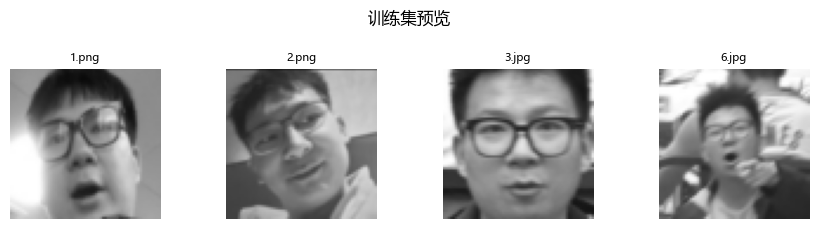

In [63]:
# --- 5.1 从文件夹读取所有图片 ---
IMAGE_DIR = NOTEBOOK_DIR / "images"
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
IMAGE_SIZE = 64

transform_img = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),  # [0, 1]
])

IMAGE_DIR.mkdir(exist_ok=True)
image_paths = sorted(
    p for p in IMAGE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS
)


tensors = []
for p in image_paths:
    img = Image.open(p).convert("L")
    tensors.append(transform_img(img))

folder_x0 = torch.stack(tensors, dim=0)  # (N, 1, 28, 28)，值域 [0, 1]

print(f"读取目录: {IMAGE_DIR.resolve()}")
print(f"共 {len(image_paths)} 张 | shape {tuple(folder_x0.shape)}")
for i, p in enumerate(image_paths):
    print(f"  [{i}] {p.name}")

# 预览前几张
n_show = min(8, len(image_paths))
cols = min(4, n_show)
rows = (n_show + cols - 1) // cols
if n_show == 1:
    fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
    axes = [ax]
else:
    fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.2 * rows))
    axes = axes.flatten()
for i in range(n_show):
    axes[i].imshow(folder_x0[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[i].set_title(image_paths[i].name, fontsize=8)
    axes[i].axis("off")
for j in range(n_show, len(axes)):
    axes[j].axis("off")
plt.suptitle("训练集预览", y=1.02)
plt.tight_layout()
plt.show()


训练集: 4 张, batch=2, 300 轮
--------------------------------------------------
Epoch  1/300  avg_loss = 0.9021
Epoch  2/300  avg_loss = 0.7943
Epoch  3/300  avg_loss = 0.8454
Epoch  4/300  avg_loss = 0.5831
Epoch  5/300  avg_loss = 0.4092
Epoch  6/300  avg_loss = 0.4702
Epoch  7/300  avg_loss = 0.2963
Epoch  8/300  avg_loss = 0.5316
Epoch  9/300  avg_loss = 0.3646
Epoch 10/300  avg_loss = 0.1266
Epoch 11/300  avg_loss = 0.2533
Epoch 12/300  avg_loss = 0.1867
Epoch 13/300  avg_loss = 0.4303
Epoch 14/300  avg_loss = 0.3196
Epoch 15/300  avg_loss = 0.0997
Epoch 16/300  avg_loss = 0.0873
Epoch 17/300  avg_loss = 0.4412
Epoch 18/300  avg_loss = 0.3676
Epoch 19/300  avg_loss = 0.3316
Epoch 20/300  avg_loss = 0.0664
Epoch 21/300  avg_loss = 0.1042
Epoch 22/300  avg_loss = 0.2851
Epoch 23/300  avg_loss = 0.0855
Epoch 24/300  avg_loss = 0.2866
Epoch 25/300  avg_loss = 0.3029
Epoch 26/300  avg_loss = 0.0899
Epoch 27/300  avg_loss = 0.2250
Epoch 28/300  avg_loss = 0.0778
Epoch 29/300  avg_loss = 0.0

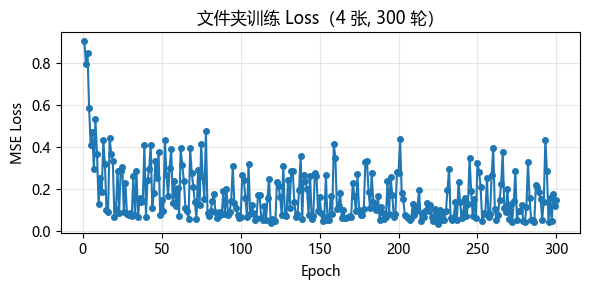

In [64]:
# --- 5.2 文件夹数据集训练（请先运行 5.1 与 train_one_epoch 定义 Cell）---
from torch.utils.data import DataLoader, TensorDataset

BATCH_SIZE = 2
EPOCHS_FOLDER = 300
LR = 1e-3
TIMESTEPS_FOLDER = 200
WEIGHT_PATH_FOLDER = NOTEBOOK_DIR / "diffusion_folder.pth"

model_folder = DiffusionModel(
    SimpleUNet(1, 32),
    image_size=IMAGE_SIZE,
    in_channels=1,
    timesteps=TIMESTEPS_FOLDER,
).to(device)

loader_folder = DataLoader(
    TensorDataset(folder_x0),
    batch_size=min(BATCH_SIZE, len(folder_x0)),
    shuffle=True,
)

optimizer_folder = torch.optim.Adam(model_folder.parameters(), lr=LR)
loss_history_folder = []

print(f"训练集: {len(folder_x0)} 张, batch={loader_folder.batch_size}, {EPOCHS_FOLDER} 轮")
print("-" * 50)
for ep in range(1, EPOCHS_FOLDER + 1):
    avg_loss = train_one_epoch(model_folder, loader_folder, optimizer_folder, device)
    loss_history_folder.append(avg_loss)
    print(f"Epoch {ep:2d}/{EPOCHS_FOLDER}  avg_loss = {avg_loss:.4f}")

print("-" * 50)
print(f"训练完成，最终 loss = {loss_history_folder[-1]:.4f}")

torch.save(
    {
        "model_state_dict": model_folder.state_dict(),
        "timesteps": TIMESTEPS_FOLDER,
        "image_size": IMAGE_SIZE,
        "in_channels": 1,
        "base_channels": 32,
        "epochs": EPOCHS_FOLDER,
        "num_images": len(folder_x0),
        "final_loss": loss_history_folder[-1],
    },
    WEIGHT_PATH_FOLDER,
)
print(f"权重已保存: {WEIGHT_PATH_FOLDER.resolve()}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, EPOCHS_FOLDER + 1), loss_history_folder, "o-", markersize=4)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title(f"文件夹训练 Loss（{len(folder_x0)} 张, {EPOCHS_FOLDER} 轮）")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


已加载: diffusion_folder.pth | 训练图数=4, final_loss=0.14606177061796188
生成完成: shape (1, 1, 64, 64)


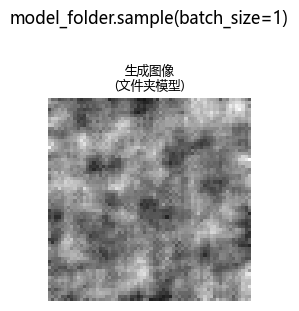

In [65]:
# --- 5.3 加载文件夹训练权重，生成 1 张图 ---
WEIGHT_PATH_FOLDER = NOTEBOOK_DIR / "diffusion_folder.pth"

ckpt_folder = torch.load(WEIGHT_PATH_FOLDER, map_location=device)
model_folder = DiffusionModel(
    SimpleUNet(ckpt_folder["in_channels"], ckpt_folder["base_channels"]),
    image_size=ckpt_folder["image_size"],
    in_channels=ckpt_folder["in_channels"],
    timesteps=ckpt_folder["timesteps"],
).to(device)
model_folder.load_state_dict(ckpt_folder["model_state_dict"])
model_folder.eval()

print(
    f"已加载: {WEIGHT_PATH_FOLDER.name} | "
    f"训练图数={ckpt_folder.get('num_images', '?')}, "
    f"final_loss={ckpt_folder.get('final_loss', 'N/A')}"
)

with torch.no_grad():
    gen_one = model_folder.sample(batch_size=1, device=device)  # (1,1,28,28)

print(f"生成完成: shape {tuple(gen_one.shape)}")

if "_show" not in globals():
    def _show(ax, tensor, title, is_noise=False):
        img = tensor[0, 0].detach().cpu()
        if is_noise:
            img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        else:
            img = (img.clamp(-1, 1) + 1) / 2
        ax.imshow(img.numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(title, fontsize=9)
        ax.axis("off")

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
_show(ax, gen_one.cpu(), "生成图像\n(文件夹模型)")
plt.suptitle("model_folder.sample(batch_size=1)", y=1.02)
plt.tight_layout()
plt.show()
